# Soft and Hard Criticism in EU Progress Reports
## Group: TOS
### Samuel Fraley, Olta Reçica, Timothy Moynihan

Introduction to Text Mining and Natural Language Processing


## Step 0 - Setup and inlined helpers

Defines all constants and helper functions used in the pipeline: the hard and soft criticism dictionaries, topic keyword sets, and functions for corpus building, scoring, topic tagging, aggregation, and regression output formatting. All functions are self-contained so the notebook runs independently of the src/ modules.

In [28]:
import io
import re
import warnings
from pathlib import Path

import matplotlib.image as mpimg
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import spacy
import statsmodels.formula.api as smf

# Locate repo root regardless of where the kernel starts
PROJECT_ROOT = next(
    p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").exists()
)

RAW_DIR = PROJECT_ROOT / "scraped" / "raw"
OUTPUT_DIR = PROJECT_ROOT / "analysis_output_notebook"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

CRITICISM_HARD = [
    "failed", "failure", "failing", "has not been implemented",
    "have not been implemented", "not implemented", "non-implementation",
    "backsliding", "backslide", "deterioration", "deteriorated",
    "regressed", "regression", "stagnation", "stagnated", "standstill",
    "violation", "violations", "breach", "breached", "impunity",
    "obstruction", "obstructed", "interference", "inadequate",
    "insufficient", "insufficiently", "absence of", "lack of",
    "deficiencies", "deficiency", "shortcomings", "shortcoming",
    "incomplete", "incompleteness", "politicisation", "politicization",
    "state capture", "systemic", "selective",
]

CRITICISM_SOFT = [
    "concern", "concerns", "concerning", "worrying", "serious concern",
    "challenge", "challenges", "challenging", "difficult", "difficulty",
    "delayed", "delay", "delays", "slow", "stalled", "limited",
    "limiting", "limited progress", "limited results", "persisting",
    "persistent", "outstanding", "remain", "remains", "problem",
    "problems", "problematic", "issue", "issues", "risk", "risks",
    "need", "needs", "needed", "require", "required", "requires",
    "must be", "needs to be", "has yet to", "have yet to",
]

TOPICS = {
    "judiciary": {
        "court", "courts", "judicial", "judge", "judges", "judgment",
        "judgement", "prosecution", "prosecutor", "prosecutors", "trial",
        "trials", "justice", "tribunal", "verdict", "appeal", "appeals",
        "conviction", "acquittal", "magistrate", "indictment", "vetting",
        "supreme court", "constitutional court", "rule of law",
    },
    "corruption": {
        "corruption", "corrupt", "fraud", "fraudulent", "bribery", "bribe",
        "transparency", "integrity", "embezzlement", "money laundering",
        "conflict of interest", "anticorruption", "anti-corruption", "illicit",
        "misconduct", "nepotism", "patronage", "accountability",
        "asset declaration", "public procurement",
    },
    "governance": {
        "administration", "governance", "public sector", "civil service",
        "institution", "institutional", "parliament", "parliamentary",
        "executive", "legislation", "legislative", "regulation", "regulatory",
        "ministry", "ministries", "capacity", "decentralisation",
        "decentralization", "local government", "public administration", "ombudsman",
    },
    "economy": {
        "economic", "economy", "market", "growth", "inflation", "employment",
        "trade", "fiscal", "budget", "investment", "gdp", "revenue",
        "privatisation", "privatization", "competition", "financial", "banking",
        "tax", "taxation", "unemployment", "poverty", "social",
    },
}

METRICS = ["criticism_hard_p1k", "criticism_soft_p1k", "severity_ratio"]
FULL_COVERAGE = ["Albania", "Kosovo", "Montenegro", "North Macedonia", "Serbia", "Turkiye"]
ISO3 = {
    "Albania": "ALB", "Bosnia And Herzegovina": "BIH", "Georgia": "GEO",
    "Kosovo": "XKX", "Moldova": "MDA", "Montenegro": "MNE",
    "North Macedonia": "MKD", "Serbia": "SRB", "Turkiye": "TUR", "Ukraine": "UKR",
}
COUNTRY_COLORS = {
    "Serbia": "tomato", "Kosovo": "steelblue", "North Macedonia": "grey",
    "Albania": "#aec6cf", "Montenegro": "#b0b0b0", "Turkiye": "#c0392b",
}

PAGE_RE = re.compile(r"={3,}\s*PAGE\s+\d+\s*={3,}")
FILE_RE = re.compile(r"^(.+?)_(\d{4})_raw\.txt$")
'''
def dict_score(text, term_list):
    text_lower = text.lower()
    n_words = len(text.split())
    raw = sum(text_lower.count(term) for term in term_list)
    per_1000 = (raw / n_words * 1000) if n_words > 0 else 0.0
    return raw, per_1000
'''
def parse_filename(name):
    m = FILE_RE.match(name)
    if not m:
        return None, None
    return m.group(1).replace("_", " ").title(), int(m.group(2))

def extract_paragraphs(text):
    text = PAGE_RE.sub("", text)
    text = re.sub(r"  \n", "\n\n", text)
    text = re.sub(r"([A-Za-z]{4,}[.!?]) \n(?=[A-Z])", r"\1\n\n", text)
    chunks = re.split(r"\n{2,}", text)
    return [c.replace("\n", " ").strip() for c in chunks]

def split_long(text, max_words=500):
    sentences = re.split(r"(?<=[.!?])\s+", text)
    chunks, current = [], []
    for sentence in sentences:
        current.append(sentence)
        if len(" ".join(current).split()) >= max_words:
            chunks.append(" ".join(current))
            current = []
    if current:
        chunks.append(" ".join(current))
    return chunks

def build_corpus(raw_dir=RAW_DIR, min_words=50, max_words=500, verbose=True):
    rows = []
    for path in sorted(Path(raw_dir).glob("*_raw.txt")):
        country, year = parse_filename(path.name)
        if country is None:
            continue
        text = path.read_text(encoding="utf-8")
        candidates = extract_paragraphs(text)
        para_id = 0
        for p in candidates:
            wc = len(p.split())
            if wc < min_words:
                continue
            sub_paras = split_long(p, max_words) if wc > max_words else [p]
            for sub in sub_paras:
                sub_wc = len(sub.split())
                if sub_wc < min_words:
                    continue
                rows.append({
                    "country": country,
                    "year": year,
                    "paragraph_id": para_id,
                    "paragraph_text": sub,
                    "word_count": sub_wc,
                })
                para_id += 1
        if verbose:
            print(f"{country:<25} {year} -> {para_id} paragraphs")
    return pd.DataFrame(rows, columns=["country", "year", "paragraph_id", "paragraph_text", "word_count"])
'''
def score_corpus(df):
    def _score_row(text):
        _, hard_p1k = dict_score(text, CRITICISM_HARD)
        _, soft_p1k = dict_score(text, CRITICISM_SOFT)
        severity = hard_p1k / soft_p1k if soft_p1k > 0 else float("nan")
        return hard_p1k, soft_p1k, severity
    if df.empty:
        return pd.concat([df, pd.DataFrame(columns=METRICS, index=df.index)], axis=1)
    scores = pd.DataFrame(
        df["paragraph_text"].apply(_score_row).tolist(),
        columns=METRICS,
        index=df.index,
    )
    return pd.concat([df, scores], axis=1)
'''
def aggregate_country_year(df_scored):
    return (
        df_scored.groupby(["country", "year"])[METRICS]
        .mean()
        .round(4)
        .reset_index()
    )

def tag_topics(df):
    df = df.copy()
    for topic, terms in TOPICS.items():
        col = f"topic_{topic}"
        df[col] = df["paragraph_text"].str.lower().apply(lambda text: any(term in text for term in terms))
    return df

def aggregate_by_topic(df_scored):
    rows = []
    for topic in TOPICS:
        col = f"topic_{topic}"
        subset = df_scored[df_scored[col]] if col in df_scored.columns else pd.DataFrame()
        for (country, year), g in subset.groupby(["country", "year"]):
            row = {"country": country, "year": year, "topic": topic, "n_paragraphs": len(g)}
            for m in METRICS:
                row[m] = round(g[m].mean(), 4)
            rows.append(row)
    return pd.DataFrame(rows, columns=["country", "year", "topic", "n_paragraphs"] + METRICS)

def stars(p):
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return ""


## Stemming

We stem single-word terms in both dictionaries using NLTK's SnowballStemmer before matching. At scoring time, each paragraph is also stemmed word-by-word, so morphological variants map to the same stem without needing to be listed separately. Multi-word phrases are matched via substring on the original lowercased text, since stemming breaks phrase boundaries.


In [29]:
from nltk.stem import SnowballStemmer

stemmer = SnowballStemmer("english")

def _prep_terms(term_list):
    single = [t for t in term_list if " " not in t]
    multi  = [t for t in term_list if " " in t]
    return [stemmer.stem(t) for t in single], multi

HARD_SINGLE_STEM, HARD_MULTI = _prep_terms(CRITICISM_HARD)
SOFT_SINGLE_STEM, SOFT_MULTI = _prep_terms(CRITICISM_SOFT)

#though we have some words that may appear twice once stemmed in our original list, this code block accounts for that!
def dict_score(text, single_stem, multi):
    tokens = re.findall(r"\b\w+\b", text.lower())
    n_words = len(tokens)
    stemmed_tokens = [stemmer.stem(t) for t in tokens]
    single_stem_set = set(single_stem)
    raw_single = sum(1 for s in stemmed_tokens if s in single_stem_set)
    raw_multi = sum(text.lower().count(phrase) for phrase in multi)
    raw = raw_single + raw_multi
    per_1000 = (raw / n_words * 1000) if n_words > 0 else 0.0    
    return raw, per_1000

def score_corpus(df):
    def _score_row(text):
        _, hard_p1k = dict_score(text, HARD_SINGLE_STEM, HARD_MULTI)
        _, soft_p1k = dict_score(text, SOFT_SINGLE_STEM, SOFT_MULTI)
        severity = hard_p1k / soft_p1k if soft_p1k > 0 else float("nan")
        return hard_p1k, soft_p1k, severity
    if df.empty:
        return pd.concat([df, pd.DataFrame(columns=METRICS, index=df.index)], axis=1)
    scores = pd.DataFrame(
        [_score_row(t) for t in df["paragraph_text"]],
        columns=METRICS,
        index=df.index,
    )
    return pd.concat([df, scores], axis=1)


## Step 1 - Build paragraph corpus

Parse all raw .txt files from scraped/raw/, extract country and year from filenames, and segment each document into paragraphs. Paragraphs under 50 words are dropped as formatting artefacts; paragraphs over 500 words are split at sentence boundaries. Produces 26,768 paragraphs across ten countries and report years 2019-2025.

In [30]:
df = build_corpus(RAW_DIR, min_words=50, max_words=500)
df.to_csv(OUTPUT_DIR / "paragraphs.csv", index=False)
print(f"Total paragraphs : {len(df):,}")
df.head()

Albania                   2019 -> 444 paragraphs
Albania                   2020 -> 547 paragraphs
Albania                   2021 -> 576 paragraphs
Albania                   2022 -> 538 paragraphs
Albania                   2023 -> 591 paragraphs
Albania                   2024 -> 364 paragraphs
Albania                   2025 -> 376 paragraphs
Bosnia And Herzegovina    2020 -> 497 paragraphs
Bosnia And Herzegovina    2021 -> 519 paragraphs
Bosnia And Herzegovina    2022 -> 548 paragraphs
Bosnia And Herzegovina    2023 -> 591 paragraphs
Bosnia And Herzegovina    2024 -> 368 paragraphs
Bosnia And Herzegovina    2025 -> 395 paragraphs
Georgia                   2023 -> 522 paragraphs
Georgia                   2024 -> 361 paragraphs
Georgia                   2025 -> 290 paragraphs
Kosovo                    2019 -> 395 paragraphs
Kosovo                    2020 -> 481 paragraphs
Kosovo                    2021 -> 457 paragraphs
Kosovo                    2022 -> 503 paragraphs
Kosovo              

,country,year,paragraph_id,paragraph_text,word_count
0,Albania,2019,0,Democracy 6 2.1.2. Public administration re...,72
1,Albania,2019,1,Albania has continued to implement the Stabili...,115
2,Albania,2019,2,Parliamentary activities were affected by a pr...,94
3,Albania,2019,3,Albania's judicial system has some level of pr...,95
4,Albania,2019,4,4 the Inter-sectoral Strategy against Corru...,171


## Step 2 - Score paragraphs

We apply the hard and soft criticism dictionaries to each paragraph using substring matching on lowercased text, normalised per 1,000 words. The severity ratio (hard / soft) is set to NaN when no soft criticism is present. 4,623 paragraphs (17%) contain hard criticism and 17,834 (66%) contain soft criticism.


In [31]:
df_scored = score_corpus(df)
df_scored.to_csv(OUTPUT_DIR / "scores.csv", index=False)

print(f"Paragraphs with any hard criticism : {(df_scored['criticism_hard_p1k'] > 0).sum():,}")
print(f"Paragraphs with any soft criticism : {(df_scored['criticism_soft_p1k'] > 0).sum():,}")
print(f"Paragraphs with severity score     : {df_scored['severity_ratio'].notna().sum():,}")

df_scored[["country", "year", "paragraph_id", "word_count", "criticism_hard_p1k", "criticism_soft_p1k", "severity_ratio"]].head()

Paragraphs with any hard criticism : 9,125
Paragraphs with any soft criticism : 17,964
Paragraphs with severity score     : 17,964


,country,year,paragraph_id,word_count,criticism_hard_p1k,criticism_soft_p1k,severity_ratio
0,Albania,2019,0,72,0.000000,0.0,NaN
1,Albania,2019,1,115,0.000000,0.0,NaN
2,Albania,2019,2,94,0.000000,0.0,NaN
3,Albania,2019,3,95,10.204082,0.0,NaN
4,Albania,2019,4,171,0.000000,0.0,NaN


### Step 2b - Dictionary seed validation

Seeds were drawn from close reading of EU progress report chapter headings and recurring critical language. We show that expanded terms co-occur heavily in seed-flagged paragraphs, confirming the expansion captured genuine rhetorical neighbours rather than arbitrary additions.

In [32]:
print("=== Hard term frequencies (corpus-wide) ===\n")
hard_freq = {}
for term in CRITICISM_HARD:
    count = df_scored["paragraph_text"].str.lower().str.contains(term).sum()
    hard_freq[term] = count

for term, count in sorted(hard_freq.items(), key=lambda x: x[1], reverse=True):
    pct = count / len(df_scored)
    print(f"  {term:<35} {count:>5} paragraphs  ({pct:.1%})")

print("\n=== Soft term frequencies (corpus-wide) ===\n")
soft_freq = {}
for term in CRITICISM_SOFT:
    count = df_scored["paragraph_text"].str.lower().str.contains(term).sum()
    soft_freq[term] = count

for term, count in sorted(soft_freq.items(), key=lambda x: x[1], reverse=True):
    pct = count / len(df_scored)
    print(f"  {term:<35} {count:>5} paragraphs  ({pct:.1%})")

=== Hard term frequencies (corpus-wide) ===

  lack of                              1364 paragraphs  (5.1%)
  insufficient                          819 paragraphs  (3.1%)
  violation                             461 paragraphs  (1.7%)
  shortcoming                           373 paragraphs  (1.4%)
  shortcomings                          367 paragraphs  (1.4%)
  violations                            316 paragraphs  (1.2%)
  breach                                270 paragraphs  (1.0%)
  absence of                            263 paragraphs  (1.0%)
  systemic                              261 paragraphs  (1.0%)
  inadequate                            248 paragraphs  (0.9%)
  interference                          232 paragraphs  (0.9%)
  backsliding                           205 paragraphs  (0.8%)
  failed                                200 paragraphs  (0.7%)
  not implemented                       185 paragraphs  (0.7%)
  incomplete                            149 paragraphs  (0.6%)
  failure 

## Step 3 - Aggregate to country-year level

Average paragraph-level scores up to the country-year level, producing 57 country-year observations. This is the basis for the trend plots and maps.

In [33]:
agg = aggregate_country_year(df_scored)
agg.to_csv(OUTPUT_DIR / "summary.csv", index=False)
agg

,country,year,criticism_hard_p1k,criticism_soft_p1k,severity_ratio
0,Albania,2019,4.7095,14.5888,0.2955
1,Albania,2020,3.8446,13.7872,0.2445
2,Albania,2021,3.7363,13.2007,0.2472
3,Albania,2022,4.1050,14.9532,0.2622
4,Albania,2023,4.6022,16.9975,0.2639
5,Albania,2024,3.8906,16.9309,0.2450
6,Albania,2025,5.1450,18.8946,0.2976
7,Bosnia And Herzegovina,2020,5.9253,19.2951,0.3531
8,Bosnia And Herzegovina,2021,6.0658,19.7329,0.3362
9,Bosnia And Herzegovina,2022,5.7956,18.6305,0.3509


## Step 4 - Tag topics

We tag each paragraph across four policy domains (judiciary, corruption, governance,economy) using keyword matching. A paragraph can match multiple topics. 22,786 paragraphs (85%) match at least one topic, with a mean of 1.45 topics per paragraph.


In [34]:
df_scored = tag_topics(df_scored)
df_scored.to_csv(OUTPUT_DIR / "scores_with_topics.csv", index=False)
topic_summary = aggregate_by_topic(df_scored)
topic_summary.to_csv(TABLE_DIR / "topic_summary.csv", index=False)

topic_cols = [c for c in df_scored.columns if c.startswith("topic_")]
topic_counts = df_scored[topic_cols].sum().rename(lambda c: c.replace("topic_", ""))

print("Paragraphs flagged per topic (corpus-wide):")
print(topic_counts.to_string())
print()
print(f"Paragraphs with at least one topic : {df_scored[topic_cols].any(axis=1).sum():,}")
print(f"Paragraphs with no topic match     : {(~df_scored[topic_cols].any(axis=1)).sum():,}")
print(f"Mean topics per paragraph          : {df_scored[topic_cols].sum(axis=1).mean():.2f}")

Paragraphs flagged per topic (corpus-wide):
judiciary      6048
corruption     4860
governance    14967
economy       12806

Paragraphs with at least one topic : 22,786
Paragraphs with no topic match     : 3,982
Mean topics per paragraph          : 1.45


## Step 5 - Spec B regression

We estimate three paragraph-level models on the six full-coverage countries (19,914 paragraphs). M1 and M2 are logistic regressions predicting hard and soft criticism presence; M3 is OLS on the severity ratio. All models include topic indicators, a median-centred year trend, and country fixed effects with North Macedonia as the reference. Standard errors are clustered by country.



In [35]:
reg = df_scored[df_scored["country"].isin(FULL_COVERAGE)].copy()
reg["hard_flag"] = (reg["criticism_hard_p1k"] > 0).astype(int)
reg["soft_flag"] = (reg["criticism_soft_p1k"] > 0).astype(int)
topic_cols = [c for c in reg.columns if c.startswith("topic_")]
for c in topic_cols:
    reg[c] = reg[c].astype(int)
reg["year_c"] = reg["year"] - reg["year"].median()

topic_terms = " + ".join(topic_cols)
rhs = f"{topic_terms} + year_c + C(country, Treatment('North Macedonia'))"
ck = {"cov_type": "cluster", "cov_kwds": {"groups": reg["country"]}}
reg_sev = reg[reg["severity_ratio"].notna()].copy()
ck_sev = {"cov_type": "cluster", "cov_kwds": {"groups": reg_sev["country"]}}

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    m1 = smf.logit(f"hard_flag ~ {rhs}", data=reg).fit(disp=False, **ck)
    m2 = smf.logit(f"soft_flag ~ {rhs}", data=reg).fit(disp=False, **ck)
    m3 = smf.ols(f"severity_ratio ~ {rhs}", data=reg_sev).fit(**ck_sev)

def extract(model, label, exponentiate):
    idx = [i for i in model.params.index if "country" in i or i.startswith("topic_") or i.startswith("year_c")]
    vals = np.exp(model.params[idx]) if exponentiate else model.params[idx]
    pvs = model.pvalues[idx]
    def clean(s):
        m = re.search(r"T\\.(.+?)\\]", s)
        if m:
            return m.group(1)
        return s.replace("topic_", "").replace("_", " ").replace("year c", "year trend")
    return pd.Series([f"{v:.3f}{stars(p)}" for v, p in zip(vals, pvs)], index=[clean(i) for i in idx], name=label)

tbl = pd.concat([
    extract(m1, "M1 hard_flag (OR)", True),
    extract(m2, "M2 soft_flag (OR)", True),
    extract(m3, "M3 severity_ratio (beta)", False),
], axis=1)

tbl.to_csv(TABLE_DIR / "spec_b_regression.csv")
print(f"n = {len(reg):,} paragraphs  |  countries: {', '.join(FULL_COVERAGE)}")
print("Reference: North Macedonia  |  SEs clustered by country")
print("* p<.05   ** p<.01   *** p<.001")
tbl

n = 19,914 paragraphs  |  countries: Albania, Kosovo, Montenegro, North Macedonia, Serbia, Turkiye
Reference: North Macedonia  |  SEs clustered by country
* p<.05   ** p<.01   *** p<.001


,M1 hard_flag (OR),M2 soft_flag (OR),M3 severity_ratio (beta)
"C(country, Treatment('North Macedonia'))[T.Albania]",0.746***,0.940***,-0.075***
"C(country, Treatment('North Macedonia'))[T.Kosovo]",1.096***,1.133***,0.011***
"C(country, Treatment('North Macedonia'))[T.Montenegro]",0.844***,0.773***,-0.015***
"C(country, Treatment('North Macedonia'))[T.Serbia]",0.829***,1.130***,-0.089***
"C(country, Treatment('North Macedonia'))[T.Turkiye]",1.274***,1.027***,0.037***
judiciary,1.319***,1.055,0.088***
corruption,1.453***,1.342***,0.071***
governance,1.575***,1.739***,0.042*
economy,1.017,1.077*,-0.015
year trend,0.994,1.021,0.001


## Step 5b - Fitted probabilities and topic effects

We extract average fitted probabilities from M1 by country and compute topic-level odds ratios with 95% confidence intervals. This is a sanity check on the country fixed effects: if the fitted rates match the observed rates, the model is accounting for all cross-country variation rather than leaving systematic residuals by country.


In [36]:
all_fitted = pd.Series(m1.predict(reg), index=reg.index)
fitted = all_fitted.groupby(reg["country"]).mean()
observed = reg.groupby("country")["hard_flag"].mean()

prob_tbl = pd.DataFrame({
    "Observed rate": observed,
    "Fitted rate (M1)": fitted,
    "Difference": fitted - observed,
}).sort_values("Fitted rate (M1)", ascending=False)

topic_idx = [i for i in m1.params.index if i.startswith("topic_")]
topic_or = np.exp(m1.params[topic_idx])
topic_lo = np.exp(m1.conf_int().loc[topic_idx, 0])
topic_hi = np.exp(m1.conf_int().loc[topic_idx, 1])
topic_p = m1.pvalues[topic_idx]

topic_tbl = pd.DataFrame({
    "Odds Ratio": [f"{v:.3f}{stars(p)}" for v, p in zip(topic_or, topic_p)],
    "95% CI": [f"[{lo:.3f}, {hi:.3f}]" for lo, hi in zip(topic_lo, topic_hi)],
}, index=[i.replace("topic_", "").replace("_", " ") for i in topic_idx])

prob_tbl.to_csv(TABLE_DIR / "hard_flag_probabilities.csv")
topic_tbl.to_csv(TABLE_DIR / "topic_odds_ratios.csv")

print("Hard-flag probability per country (M1, North Macedonia reference)")
display(prob_tbl.style.format({"Observed rate": "{:.1%}", "Fitted rate (M1)": "{:.1%}", "Difference": "{:.1%}"}))
print("M1 topic effects - hard_flag")
topic_tbl

Hard-flag probability per country (M1, North Macedonia reference)


,Observed rate,Fitted rate (M1),Difference
country,,,
Turkiye,39.6%,39.6%,0.0%
Kosovo,36.8%,36.8%,0.0%
North Macedonia,34.9%,34.9%,0.0%
Montenegro,31.3%,31.3%,0.0%
Serbia,30.6%,30.6%,0.0%
Albania,28.5%,28.5%,0.0%


M1 topic effects - hard_flag


,Odds Ratio,95% CI
judiciary,1.319***,"[1.170, 1.487]"
corruption,1.453***,"[1.325, 1.592]"
governance,1.575***,"[1.374, 1.805]"
economy,1.017,"[0.925, 1.117]"


## Extra step - Preprocessing sensitivity check

We test whether the country rankings change under alternative paragraph length thresholds. Replacing the 500-word cap with 300 words shifts no country's score by more than 0.3%. Lowering the minimum from 50 to 30 words produces larger changes (up to 11% for Montenegro) but leaves the country ranking identical. This confirms the core cross-country comparisons are not an artefact of the length thresholds chosen.

In [37]:
configs = [
    ("baseline (50-500)",    50, 500),
    ("min=30, max=500",      30, 500),
    ("min=50, max=300",      50, 300),
]

sens_results = []
for label, mn, mx in configs:
    df_s = build_corpus(RAW_DIR, min_words=mn, max_words=mx, verbose=False)
    df_s = score_corpus(df_s)
    agg_s = aggregate_country_year(df_s)
    agg_s = agg_s[agg_s["country"].isin(FULL_COVERAGE)]
    mean_hard = agg_s.groupby("country")["criticism_hard_p1k"].mean().round(3)
    mean_hard.name = label
    sens_results.append(mean_hard)

sens_tbl = pd.concat(sens_results, axis=1)

# Add pct change columns relative to baseline
for col in sens_tbl.columns[1:]:
    sens_tbl[f"{col} (% change)"] = ((sens_tbl[col] - sens_tbl["baseline (50-500)"]) / sens_tbl["baseline (50-500)"] * 100).round(1).astype(str) + "%"

sens_tbl.to_csv(TABLE_DIR / "sensitivity_preprocessing.csv")
print("Preprocessing sensitivity — mean hard criticism p1k by country")
print("Reference: baseline (min=50, max=500)")
print()
sens_tbl

Preprocessing sensitivity — mean hard criticism p1k by country
Reference: baseline (min=50, max=500)



,baseline (50-500),"min=30, max=500","min=50, max=300","min=30, max=500 (% change)","min=50, max=300 (% change)"
country,,,,,
Albania,4.290,4.491,4.287,4.7%,-0.1%
Kosovo,5.755,5.540,5.756,-3.7%,0.0%
Montenegro,4.788,4.629,4.779,-3.3%,-0.2%
North Macedonia,5.168,5.169,5.162,0.0%,-0.1%
Serbia,4.017,4.086,4.028,1.7%,0.3%
Turkiye,6.047,6.031,6.030,-0.3%,-0.3%


## Extra step - Serbia soft criticism examples

We pull Serbia paragraphs with high soft criticism (above 5 p1k) and zero hard criticism to illustrate qualitatively what the low severity ratio looks like on the page. These are paragraphs where the EU is clearly aware of a problem but expresses it entirely in hedged language, the pattern the regression captures in Serbia's M1 and M3 coefficients.



In [38]:
serbia_soft = df_scored[
    (df_scored["country"] == "Serbia") &
    (df_scored["criticism_soft_p1k"] > 5) &
    (df_scored["criticism_hard_p1k"] == 0)
].sort_values("criticism_soft_p1k", ascending=False)

for i, row in serbia_soft.head(5).iterrows():
    print(f"Year: {row['year']} | soft p1k: {row['criticism_soft_p1k']:.2f}")
    print(row['paragraph_text'])
    print("---")

Year: 2023 | soft p1k: 115.38
Serbia has a good level of preparation in company law. Limited progress was made with the  mandatory electronic filing of applications for incorporation for joint-stock and limited liability  companies, and for limited and general partnerships. Further alignment is needed in the  company law area. Therefore, last year’s recommendation remains valid.
---
Year: 2022 | soft p1k: 104.48
Serbia remains moderately prepared on free movement of capital. Limited  progress  was  made overall during the reporting period, with the adoption of the national money laundering  risk assessment, the national terrorism financing risk assessment, the money laundering risk  assessment in the virtual assets area and the risk assessment in the weapons of mass  destruction (WMD) in the proliferation financing area. Last year’s recommendations thus  remain valid.
---
Year: 2019 | soft p1k: 94.12
Better cooperation mechanisms between the line ministries and consumer organisations n

## Step 6 - Figures

### Hard criticism, soft criticism, and severity ratio across six EU candidate countries, 2019–2025

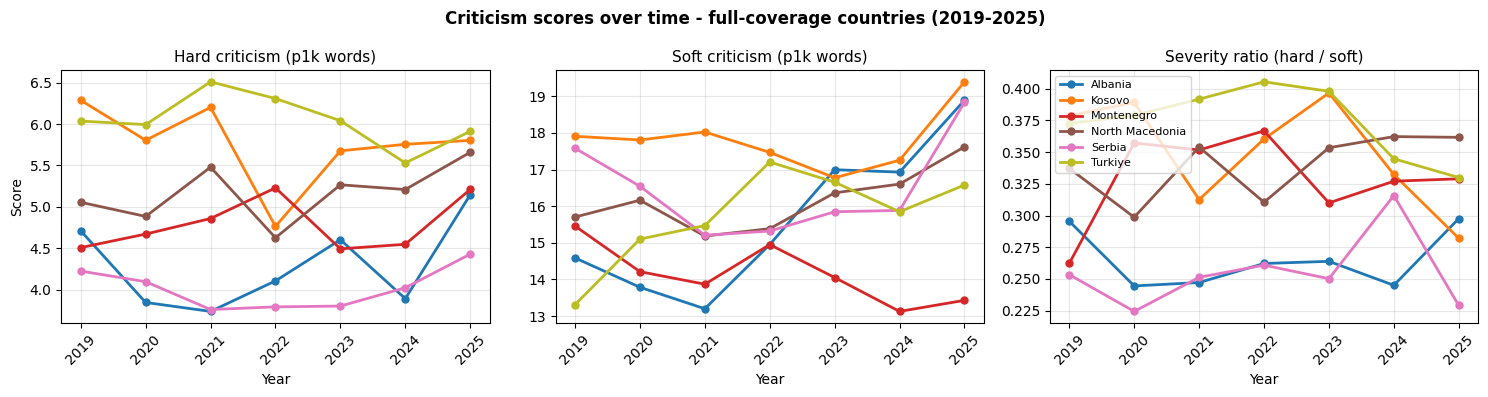

In [39]:
sub = agg[agg["country"].isin(FULL_COVERAGE)].sort_values("year")
colors = {c: plt.cm.tab10(i / len(FULL_COVERAGE)) for i, c in enumerate(FULL_COVERAGE)}
panels = [
    ("criticism_hard_p1k", "Hard criticism (p1k words)"),
    ("criticism_soft_p1k", "Soft criticism (p1k words)"),
    ("severity_ratio", "Severity ratio (hard / soft)"),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
for ax, (col, ylabel) in zip(axes, panels):
    for country, grp in sub.groupby("country"):
        ax.plot(grp["year"], grp[col], marker="o", linewidth=2, markersize=5, color=colors[country], label=country)
    ax.set_title(ylabel, fontsize=11)
    ax.set_xlabel("Year")
    ax.set_xticks(sorted(sub["year"].unique()))
    ax.tick_params(axis="x", labelrotation=45)
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel("Score")
axes[2].legend(fontsize=8, loc="upper left")
plt.suptitle("Criticism scores over time - full-coverage countries (2019-2025)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

fig.savefig(FIGURE_DIR / "full_coverage_trends.png", dpi=200, bbox_inches="tight")

### Kosovo / Serbia / North Macedonia over time

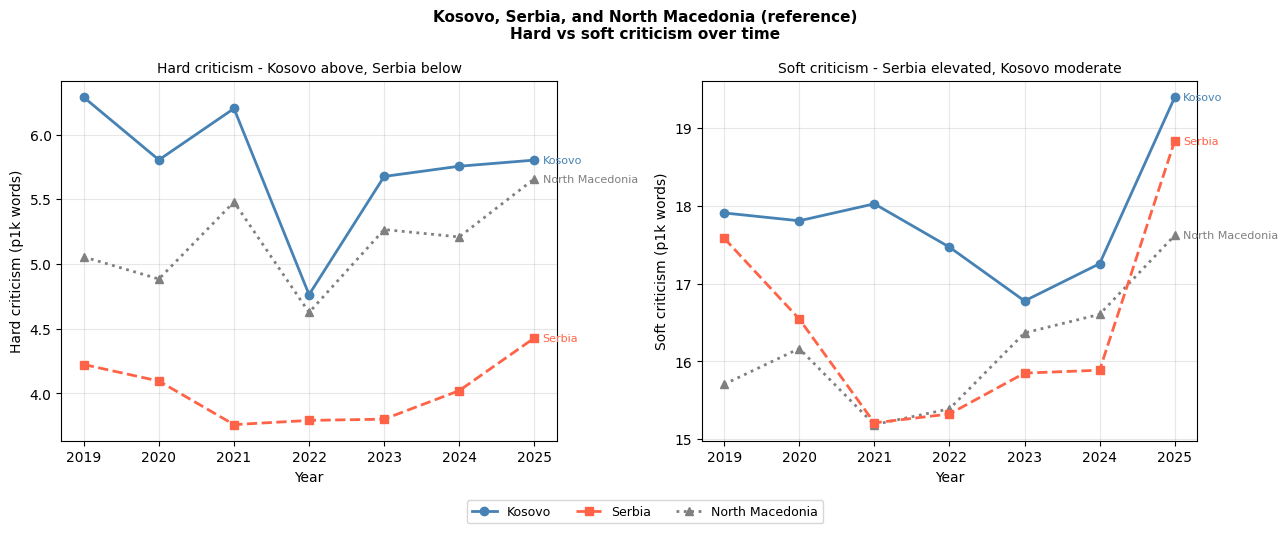

In [40]:
focus = ["Kosovo", "Serbia", "North Macedonia"]
styles = {"Kosovo": ("steelblue", "o", "-"), "Serbia": ("tomato", "s", "--"), "North Macedonia": ("grey", "^", ":")}
sub = agg[agg["country"].isin(focus)].sort_values("year")

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True)
panels = [
    (axes[0], "criticism_hard_p1k", "Hard criticism (p1k words)", "Hard criticism - Kosovo above, Serbia below"),
    (axes[1], "criticism_soft_p1k", "Soft criticism (p1k words)", "Soft criticism - Serbia elevated, Kosovo moderate"),
]

for ax, col, ylabel, title in panels:
    for country, grp in sub.groupby("country"):
        color, marker, ls = styles[country]
        ax.plot(grp["year"], grp[col], color=color, marker=marker, linestyle=ls, linewidth=2, markersize=6)
    ax.set_xlabel("Year")
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=10)
    ax.set_xticks(sorted(sub["year"].unique()))
    ax.grid(True, alpha=0.3)

for country, grp in sub.groupby("country"):
    color, _, _ = styles[country]
    for col, ax in [(panels[0][1], axes[0]), (panels[1][1], axes[1])]:
        row = grp[grp["year"] == grp["year"].max()]
        if not row.empty:
            ax.annotate(country, xy=(row["year"].values[0], row[col].values[0]), xytext=(6, 0), textcoords="offset points", fontsize=8, color=color, va="center")

legend_handles = [mlines.Line2D([], [], color=c, marker=m, linestyle=ls, linewidth=2, markersize=6, label=country) for country, (c, m, ls) in styles.items()]
fig.legend(handles=legend_handles, loc="lower center", ncol=3, fontsize=9, bbox_to_anchor=(0.5, -0.06))
plt.suptitle("Kosovo, Serbia, and North Macedonia (reference)\nHard vs soft criticism over time", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

### Serbia handled with care scatter analysis

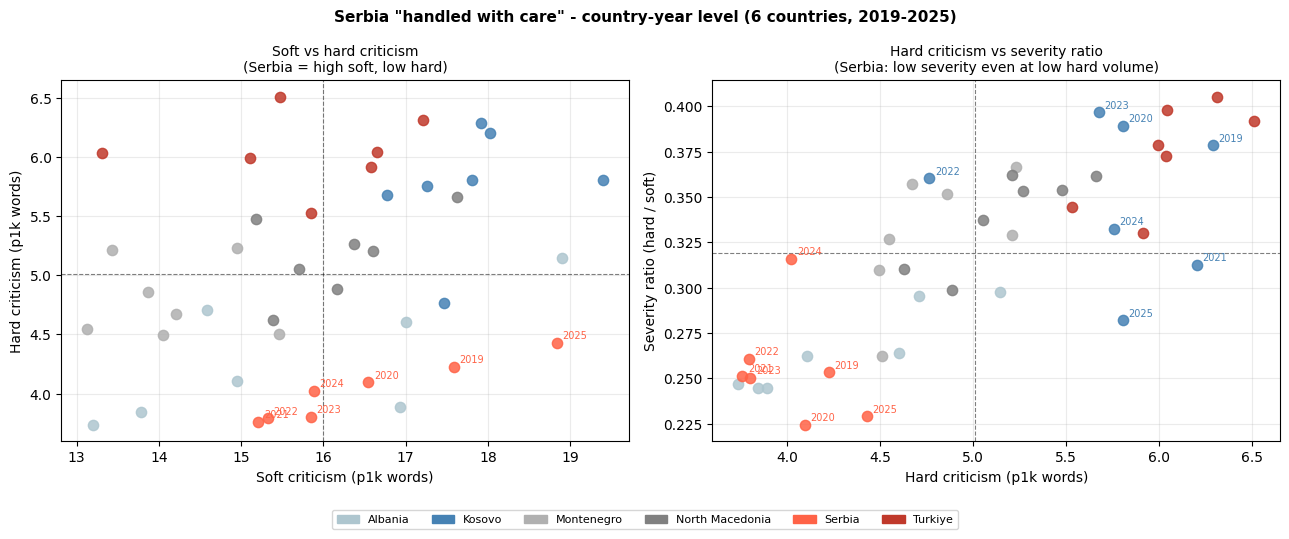

In [41]:
agg_fc = agg[agg["country"].isin(FULL_COVERAGE)].copy()
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
for country, grp in agg_fc.groupby("country"):
    color = COUNTRY_COLORS[country]
    ax.scatter(grp["criticism_soft_p1k"], grp["criticism_hard_p1k"], color=color, s=55, zorder=3, alpha=0.85)
    if country == "Serbia":
        for _, row in grp.iterrows():
            ax.annotate(str(int(row["year"])), (row["criticism_soft_p1k"], row["criticism_hard_p1k"]), xytext=(4, 3), textcoords="offset points", fontsize=7, color=color)
xmean = agg_fc["criticism_soft_p1k"].mean()
ymean = agg_fc["criticism_hard_p1k"].mean()
ax.axvline(xmean, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
ax.axhline(ymean, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
ax.set_xlabel("Soft criticism (p1k words)")
ax.set_ylabel("Hard criticism (p1k words)")
ax.set_title("Soft vs hard criticism\n(Serbia = high soft, low hard)", fontsize=10)
ax.grid(True, alpha=0.25)

ax = axes[1]
for country, grp in agg_fc.groupby("country"):
    color = COUNTRY_COLORS[country]
    ax.scatter(grp["criticism_hard_p1k"], grp["severity_ratio"], color=color, s=55, zorder=3, alpha=0.85)
    if country in ("Serbia", "Kosovo"):
        for _, row in grp.iterrows():
            ax.annotate(str(int(row["year"])), (row["criticism_hard_p1k"], row["severity_ratio"]), xytext=(4, 3), textcoords="offset points", fontsize=7, color=color)
ax.axvline(agg_fc["criticism_hard_p1k"].mean(), color="black", linewidth=0.8, linestyle="--", alpha=0.5)
ax.axhline(agg_fc["severity_ratio"].mean(), color="black", linewidth=0.8, linestyle="--", alpha=0.5)
ax.set_xlabel("Hard criticism (p1k words)")
ax.set_ylabel("Severity ratio (hard / soft)")
ax.set_title("Hard criticism vs severity ratio\n(Serbia: low severity even at low hard volume)", fontsize=10)
ax.grid(True, alpha=0.25)

handles = [mpatches.Patch(color=COUNTRY_COLORS[c], label=c) for c in FULL_COVERAGE]
fig.legend(handles=handles, loc="lower center", ncol=6, fontsize=8, bbox_to_anchor=(0.5, -0.07))
plt.suptitle('Serbia "handled with care" - country-year level (6 countries, 2019-2025)', fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

### Map: hard criticism and severity ratio (2025)

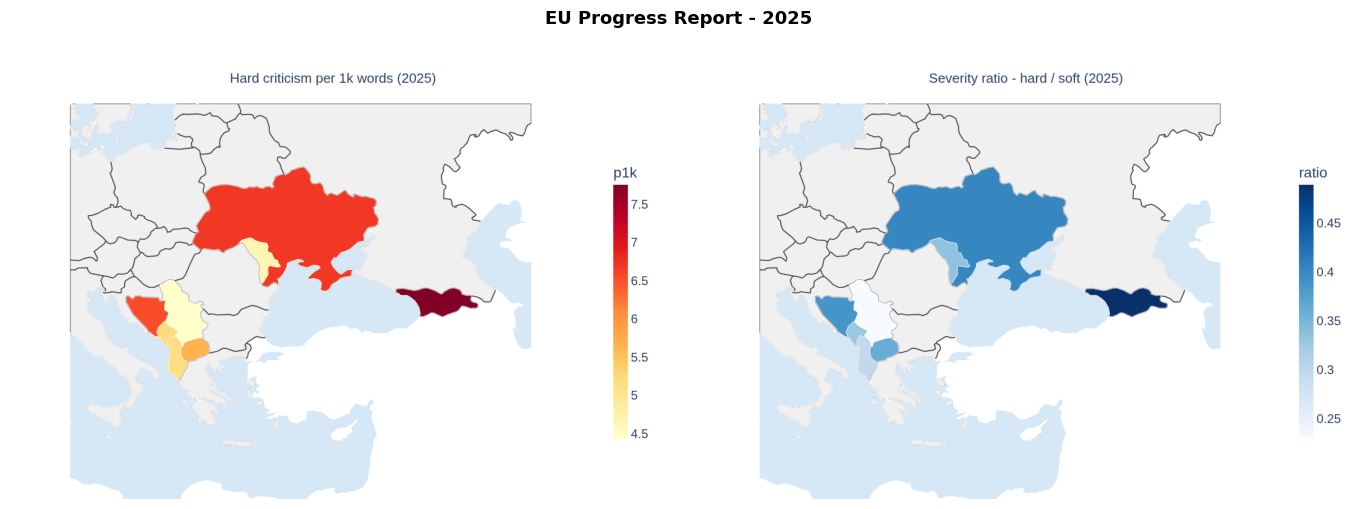

In [42]:
agg_2025 = agg[agg["year"] == 2025].copy()
agg_2025["iso3"] = agg_2025["country"].map(ISO3)

geo = dict(
    scope="europe",
    resolution=50,
    showcoastlines=True, coastlinecolor="white",
    showland=True, landcolor="#f0f0f0",
    showocean=True, oceancolor="#d6e8f5",
    showlakes=False,
    lataxis_range=[33, 55],
    lonaxis_range=[13, 50],
)

def make_map(locations, z, text, colorscale, colorbar_title, title):
    fig = go.Figure(go.Choropleth(
        locations=locations,
        z=z,
        text=text,
        locationmode="ISO-3",
        colorscale=colorscale,
        colorbar=dict(title=colorbar_title, thickness=14, len=0.75),
        hovertemplate="%{text}: %{z:.3f}<extra></extra>",
        marker_line_color="white",
        marker_line_width=0.5,
    ))
    fig.update_layout(title=dict(text=title, x=0.5, font_size=13), geo=geo, height=420, width=620, margin=dict(l=0, r=0, t=40, b=0))
    return fig

fig_hard = make_map(agg_2025["iso3"], agg_2025["criticism_hard_p1k"], agg_2025["country"], "YlOrRd", "p1k", "Hard criticism per 1k words (2025)")
fig_sev = make_map(agg_2025["iso3"], agg_2025["severity_ratio"], agg_2025["country"], "Blues", "ratio", "Severity ratio - hard / soft (2025)")

fig_hard.write_image(str(FIGURE_DIR / "map_hard_2025.png"), scale=2)
fig_sev.write_image(str(FIGURE_DIR / "map_severity_2025.png"), scale=2)

img_hard = mpimg.imread(io.BytesIO(fig_hard.to_image(format="png", scale=2)))
img_sev = mpimg.imread(io.BytesIO(fig_sev.to_image(format="png", scale=2)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, img in zip(axes, [img_hard, img_sev]):
    ax.imshow(img)
    ax.axis("off")

plt.suptitle("EU Progress Report - 2025", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()